# BIOMASS L1a SLC Full-Catalog Swath Scanner & Ocean/Land/Coastal Classifier

**Purpose:** Notebook written dedicated for use of future users/interns of Biomass Datasets to quickly see swath paths acquired so far. Used to complete a full scan the ESA MAAP `BiomassLevel1a` STAC collection to build a deduplicated catalog of every unique swath location (`grid:code`) ever imaged by BIOMASS, classify each by ocean/coastal/land fraction, and visualize coverage on a world map.

**Why this exists:** BIOMASS reflies the same swath location many times over its mission for tomographic repeat cycles. If you only need to know *where*
BIOMASS has imaged (not every individual acquisition), you don't need to process all ~200,000+ granules, you need the much smaller set of unique swath footprints. This notebook builds that catalog once, resumably, and lets you re-plot it anytime without rescanning.

**Runtime:** A full scan of the entire collection takes on the order of 3-5+ hours at time of writing, depending on API load and connection stability. It WILL be interrupted by transient server errors (502 Bad Gateway is common), this is expected and handled automatically. See "Known issues fixed in this version" below before you start.

**Author:** Orlaith Doyle, ESA-ESTEC Biomass Intern with Supervisor Bjorn Rommen. Dated: 24/07/2026.

## How to use this notebook
**Pre-reqs:** Make sure to download the accompanying `all_swaths.csv` and `all_acquisitions.csv` files if you'd like to cut your processing time down, and also ensure you have a valid and operational ESA MAAP account as it'll be need if you hope to run a fresh scan of products to keep your work more updated.

1. Run **Section 1 (Configuration)** once per environment, update the paths to match your machine.
2. Run **Section 2 (Setup / Authentication)** every time you start or resume a session, it reloads your credentials, reconnects to the catalog, and
   restores progress from the last checkpoint (if any exists).
3. Run **Section 3 (Scan)**. This is safe to interrupt and re-run: it checkpoints every `BATCH_SIZE` granules and resumes from exactly where it left off. If it prints `"Done! Reached the end of the collection"`, the scan is genuinely complete (see caveats below on why this wasn't always true in earlier versions).
4. Once finished (or at any partial checkpoint if you want a snapshot), run **Section 4 (Diagnostics)** to sanity-check what you have, and **Section 5 (Visualization)** to produce the classified world map.

## Known issues fixed in this version (read before modifying the scan logic)
These bugs cost real time to discover and fix during the original scan, so definitely worth understanding before touching this code:
**Server-side product-type filtering silently drops valid data.**
An earlier version filtered with `filter="product:type='S1_SCS__1S'"` on the server side. This silently excluded `S2_SCS__1S` (confirmed: ocean/calibration acquisitions) and `S3_SCS__1S` with no error, just missing data.
**Fix:** no server-side product-type filter; every item is fetched and checked client-side against `product_type.endswith("SCS__1S")`, which transparently covers S1/S2/S3 (or any future SN variant) without needing to know the full set of valid values in advance.

**Any API error was misread as "end of collection."** When the STAC item iterator raises an error mid-page (502 Bad Gateway, the ~100,000-row `startRecord` pagination cap the API enforces, connection resets, etc.), the underlying HTTP session becomes unusable. Calling `next()` again on that same (now-broken) iterator doesn't retry the failed request, it raises a spurious `StopIteration`, which earlier code misread as *genuine* end-of-collection, silently truncating scans after a single transient error.
**Fix:** any `APIError` immediately breaks out to an outer loop that reconnects with a brand-new `search()` call (fresh HTTP session, pagination reset), using the datetime resume filter to continue exactly where the scan left off. Only a real `StopIteration` from a *working* iterator is treated as completion.

**Discovery is NOT a smooth saturating curve, don't stop early.** Plotting cumulative unique swaths against cumulative items scanned shows a **stepped** pattern: long flat plateaus (pure repeat-visit territory) punctuated by sharp bursts of new discovery, unpredictably distributed across the mission timeline. In this project's run, roughly 11% of the final unique-swath total was discovered in the *last 15%* of the scan. **Do not assume the count has "basically converged" from an early or partial run**, always check the actual discovery curve (Section 4.2) before deciding a partial scan is representative.

Good luck and hope it helps... :) 

## 1. Configuration

Edit the values in this cell for your environment. Nothing elsewhere in the
notebook should need editing.


In [1]:
from pathlib import Path
SECRETS_PATH = Path.home() / 'STEP_BACK' / 'secrets.txt' # where your secrets.txt lives (see "Credentials" note below)
BASE_DIR = Path.home() / 'STEP_BACK' / 'sidequest_check' # base working directory for this scan's outputs
COLLECTION_ID = "BiomassLevel1a" # STAC collection to scan
KEYCLOAK_TOKEN_URL = "https://iam.maap.eo.esa.int/realms/esa-maap/protocol/openid-connect/token" # MAAP endpoints (confirmed working as of this project)
CATALOG_URL = "https://catalog.maap.eo.esa.int/catalogue/"
BATCH_SIZE = 500 # checkpoint interval (granules per checkpoint write)
# reconnect behaviour on API errors
MAX_OUTER_ATTEMPTS = 30 # how many reconnects the scan cell will attempt before giving up - I'd keep this high (>30) because it will need to reconnect a lot!
OUTER_RECONNECT_DELAY = 30 # seconds to wait before each reconnect - This should 
# classification thresholds for the final ocean/coastal/land plot
OCEAN_THRESHOLD = 0.95 # ocean_fraction >= this -> classified "ocean"
LAND_ONLY_THRESHOLD = 0.05 # ocean_fraction <= this -> classified "land", anything in between -> "coastal"
# derived paths (no need to edit below this line)
BASE_DIR.mkdir(parents=True, exist_ok=True)
STATE_FILE = BASE_DIR / "scan_state.json"
ALL_SWATHS_CSV = BASE_DIR / "all_swaths.csv"
ALL_ACQUISITIONS_CSV = BASE_DIR / "all_acquisitions.csv"
OUTPUT_DIR = BASE_DIR
print("Configuration set:")
print(f" SECRETS_PATH = {SECRETS_PATH}")
print(f" BASE_DIR = {BASE_DIR}")
print(f" STATE_FILE = {STATE_FILE}")
print(f" ALL_SWATHS_CSV = {ALL_SWATHS_CSV}")
print(f" ALL_ACQUISITIONS_CSV = {ALL_ACQUISITIONS_CSV}")

Configuration set:
 SECRETS_PATH = C:\Users\Orlaith.Doyle\STEP_BACK\secrets.txt
 BASE_DIR = C:\Users\Orlaith.Doyle\STEP_BACK\sidequest_check
 STATE_FILE = C:\Users\Orlaith.Doyle\STEP_BACK\sidequest_check\scan_state.json
 ALL_SWATHS_CSV = C:\Users\Orlaith.Doyle\STEP_BACK\sidequest_check\all_swaths.csv
 ALL_ACQUISITIONS_CSV = C:\Users\Orlaith.Doyle\STEP_BACK\sidequest_check\all_acquisitions.csv


### Credentials

You'll need to make a `secrets.txt` file, it must be a plain Python-syntax file (never commit this to version control) containing the lines which you can copy from and edit below. I have included a screenshot of my text file for guidance, please note - I have editted the image to keep my token secure:
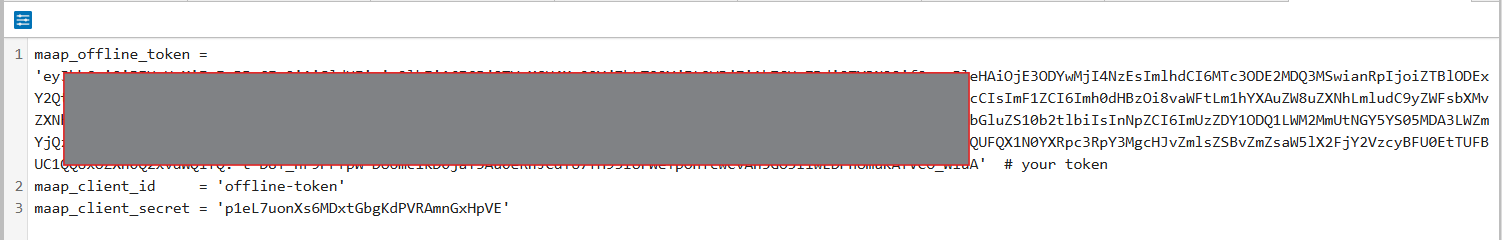

```python
maap_offline_token = 'your-offline-token-here'
maap_client_id = 'offline-token'
maap_client_secret = 'your-client-secret-here'
```
Obtain these credentials from your ESA MAAP account; [https://explorer.maap.eo.esa.int/]. The client secret is required, authenticating without it fails with a `401 unauthorized_client` error. If you have any doubts with this I would follow the guidelines on the MAAP website for account creation and token authentication.


## 2. Setup / Authentication

Run this cell every time you start a new session (new kernel, new day, resuming after a break). It is idempotent and safe to re-run at any time, re-running it mid-scan will simply reload whatever is currently checkpointed on disk.
If `scan_state.json` exists, progress resumes from there. If it's missing but `all_acquisitions.csv` already has data (e.g. the state file was lost or renamed), the checkpoint is automatically reconstructed from the CSV instead of starting over from zero.

In [2]:
# SETUP CELL; run this at the start of every session
exec(SECRETS_PATH.read_text())   # defines maap_offline_token, maap_client_id, maap_client_secret
# Imports
import json
import gc
import time
import requests
import pandas as pd
from shapely.geometry import shape
from shapely.ops import unary_union
from pystac_client import Client
from pystac_client.exceptions import APIError
import cartopy.io.shapereader as shpreader
# Authentication (MAAP via Keycloak)
def get_access_token():
    resp = requests.post(
        KEYCLOAK_TOKEN_URL,
        data={
            "grant_type": "refresh_token",
            "client_id": maap_client_id,
            "client_secret": maap_client_secret,
            "refresh_token": maap_offline_token,
            "scope": "offline_access openid",
        },
    )
    resp.raise_for_status()
    return resp.json()["access_token"]

access_token = get_access_token()
print("Access token retrieved successfully.")

# STAC catalog connection
catalog = Client.open(
    CATALOG_URL,
    headers={"Authorization": f"Bearer {access_token}"},
)
# Resume state; loads scan_state.json if present; reconstructs from the CSVs if it's missing but real data already exists
if STATE_FILE.exists():
    with open(STATE_FILE) as f:
        state = json.load(f)
    print(f"Reloaded checkpoint: {state.get('n_scanned', 0)} granules already scanned, "
          f"{len(state.get('seen_grid_codes', []))} unique swaths, "
          f"last_datetime={state.get('last_datetime')}")

elif ALL_ACQUISITIONS_CSV.exists():
    print(f"No {STATE_FILE.name} found, but {ALL_ACQUISITIONS_CSV.name} exists"
          f"reconstructing checkpoint from existing CSV data instead of starting fresh.")

    acq_df = pd.read_csv(ALL_ACQUISITIONS_CSV)
    acq_df["datetime"] = pd.to_datetime(acq_df["datetime"])

    n_scanned = len(acq_df)
    seen_grid_codes = sorted(acq_df["grid_code"].dropna().unique().tolist())
    max_dt = acq_df["datetime"].max()
    last_datetime = max_dt.strftime("%Y-%m-%dT%H:%M:%S.%f")[:-3] + "Z"
    boundary_ids = acq_df.loc[acq_df["datetime"] == max_dt, "id"].tolist()

    state = {
        "n_scanned": n_scanned,
        "seen_grid_codes": seen_grid_codes,
        "last_datetime": last_datetime,
        "boundary_ids": boundary_ids,
    }
    with open(STATE_FILE, "w") as f:
        json.dump(state, f)

    print(f"Reconstructed checkpoint: {n_scanned} granules, {len(seen_grid_codes)} unique swaths, "
          f"last_datetime={last_datetime}, {len(boundary_ids)} boundary id(s)")
else:
    state = {"n_scanned": 0}
    print("No checkpoint and no existing CSV data found... starting fresh.")
    
# Land geometry (for ocean-fraction masking) Natural Earth 50m land, lake-aware (lakes subtracted so inland seas like the Caspian correctly read as water, not land)
land_shp = shpreader.natural_earth(resolution="50m", category="physical", name="land")
land_geoms = [shape(g) for g in shpreader.Reader(land_shp).geometries() if g is not None]
land_raw_union = unary_union(land_geoms)
lakes_shp = shpreader.natural_earth(resolution="50m", category="physical", name="lakes")
lake_geoms = [shape(g) for g in shpreader.Reader(lakes_shp).geometries() if g is not None]
lakes_union = unary_union(lake_geoms) if lake_geoms else None
land_union = land_raw_union.difference(lakes_union) if lakes_union is not None else land_raw_union
print(f"land_union built: {len(land_geoms)} land polygons, lake-aware (lakes subtracted)")
print("\nSetup complete. catalog, COLLECTION_ID, STATE_FILE, ALL_SWATHS_CSV, "
      "ALL_ACQUISITIONS_CSV, BATCH_SIZE, land_union, state are all defined.")

Access token retrieved successfully.
Reloaded checkpoint: 209572 granules already scanned, 5153 unique swaths, last_datetime=2026-07-23T19:14:00.640Z
land_union built: 1420 land polygons, lake-aware (lakes subtracted)

Setup complete. catalog, COLLECTION_ID, STATE_FILE, ALL_SWATHS_CSV, ALL_ACQUISITIONS_CSV, BATCH_SIZE, land_union, state are all defined.


## 3. Scan the Collection

Long-running, resumable, self-healing scan of the full STAC collection.

- **Deduplicates by `grid:code`** (the track/frame identifier for a swath location), once a location has been seen, later revisits are logged as "dupes" and skipped from the expensive land-intersection calculation, but every individual acquisition is still logged to `all_acquisitions.csv`.
- **Checkpoints every `BATCH_SIZE` granules** to both CSVs and `scan_state.json`, so nothing is lost on interruption.
- **Reconnects automatically** on any API error (see "Known issues" above) rather than retrying a broken iterator.
- **Sorted resume**: results are explicitly sorted by ascending datetime (`sortby="+properties.datetime"`), so "resume from the last datetime seen" is well-defined. Ties at the exact same datetime are handled via `boundary_ids`, which tracks every id already processed at the current max datetime, avoiding both double-counting and silently skipped ties.
- **Product type filtering is client-side**, accepting any `_SCS__1S` product (S1, S2, S3, or any future variant)... see "Known issues" #1 above for why a server-side filter is unsafe here.

**Just run the cell below.** If it stops before printing `"Done! reached the end of the collection"`, your progress is saved. Re-run this same cell (after re-running Section 2 if you're in a new session) to continue.

In [3]:
# SCAN CELL; self-healing, resumable, checkpointed every BATCH_SIZE granules
class APIReconnectNeeded(Exception):
    """Raised on ANY APIError mid-scan, signals the outer loop to reconnect with a fresh search(), rather than retrying the same (now-unreliable) iterator."""
    pass

def next_or_reconnect(it):
    try:
        return next(it)
    except StopIteration:
        raise
    except APIError as e:
        raise APIReconnectNeeded(str(e)) from e

seen_grid_codes = set(state.get("seen_grid_codes", []))
write_header = not ALL_SWATHS_CSV.exists()
write_header_acq = not ALL_ACQUISITIONS_CSV.exists()
n_new = state["n_scanned"]
n_duplicate_skips = 0
n_wrong_product_type_skips = 0
last_seen_datetime = state.get("last_datetime")

boundary_ids = set(state.get("boundary_ids", []))
if not boundary_ids and state.get("last_id"):
    boundary_ids = {state["last_id"]}

session_start_scanned = n_new
session_start_remaining = None

outer_attempt = 0
finished = False

while outer_attempt < MAX_OUTER_ATTEMPTS and not finished:
    outer_attempt += 1
    resume_datetime = state.get("last_datetime")
    datetime_filter = f"{resume_datetime}/.." if resume_datetime else None

    search = catalog.search(
        collections=[COLLECTION_ID],
        method="GET",
        datetime=datetime_filter,
        sortby="+properties.datetime",
        max_items=None,
    )

    try:
        remaining_now = search.matched()
    except Exception:
        remaining_now = None
    if session_start_remaining is None:
        session_start_remaining = remaining_now

    label = f"datetime >= {resume_datetime}" if resume_datetime else "the beginning"
    print(f"[Reconnect number{outer_attempt}] Resuming from {label} , {remaining_now} granules remain")

    item_iter = search.items()
    batch_rows = []
    acquisitions_batch = []
    page_error = False

    try:
        while True:
            try:
                item = next_or_reconnect(item_iter)
            except StopIteration:
                finished = True
                break
            except APIReconnectNeeded as e:
                print(f"\n  API error requires reconnect: {e}")
                page_error = True
                break

            item_dt = item.properties.get("datetime")

            # Datetime filter is inclusive: at the resume boundary, skip only ids we've already processed. Any tie we hadn't reached yet is NOT in boundary_ids and still gets processed normally.
            if item_dt == resume_datetime and item.id in boundary_ids:
                continue

            # Client-side product type check, accepts any SCS product (S1, S2, S3, ...) rather than trusting a server-side filter.
            product_type = item.properties.get("product:type", "")
            if not product_type.endswith("SCS__1S"):
                n_wrong_product_type_skips += 1
                continue

            n_new += 1
            if item_dt != last_seen_datetime:
                boundary_ids = set()
            last_seen_datetime = item_dt
            boundary_ids.add(item.id)

            grid_code = item.properties.get("grid:code")

            # Log EVERY acquisition (including repeats), lightweight, no geometry, since geometry is essentially fixed per grid_code and gets joined back in from ALL_SWATHS_CSV at plot time.
            acquisitions_batch.append({
                "id": item.id,
                "grid_code": grid_code,
                "datatake_id": item.properties.get("eopf:datatake_id"),
                "absolute_orbit": item.properties.get("sat:absolute_orbit"),
                "datetime": item_dt,
                "orbit_state": item.properties.get("sat:orbit_state"),
                "product_type": product_type,
            })

            if grid_code is not None and grid_code in seen_grid_codes:
                n_duplicate_skips += 1
            else:
                if grid_code is not None:
                    seen_grid_codes.add(grid_code)
                try:
                    footprint = shape(item.geometry)
                    if footprint.area > 0:
                        land_overlap = footprint.intersection(land_union)
                        ocean_fraction = 1 - (land_overlap.area / footprint.area)
                    else:
                        ocean_fraction = None
                except Exception:
                    ocean_fraction = None

                # Save every unique swath's fraction + geometry regardless of value, thresholds are applied later at plot time, so no data is thrown away here.
                if ocean_fraction is not None:
                    batch_rows.append({
                        "id": item.id,
                        "grid_code": grid_code,
                        "geometry_wkt": footprint.wkt,
                        "ocean_fraction": ocean_fraction,
                        "orbit_state": item.properties.get("sat:orbit_state"),
                        "datetime": item_dt,
                        "product_type": product_type,
                    })

            if n_new % BATCH_SIZE == 0:
                if batch_rows:
                    pd.DataFrame(batch_rows).to_csv(ALL_SWATHS_CSV, mode="a", header=write_header, index=False)
                    write_header = False
                    batch_rows = []
                if acquisitions_batch:
                    pd.DataFrame(acquisitions_batch).to_csv(ALL_ACQUISITIONS_CSV, mode="a", header=write_header_acq, index=False)
                    write_header_acq = False
                    acquisitions_batch = []
                state["n_scanned"] = n_new
                state["seen_grid_codes"] = list(seen_grid_codes)
                state["last_datetime"] = last_seen_datetime
                state["boundary_ids"] = list(boundary_ids)
                state.pop("last_id", None)
                with open(STATE_FILE, "w") as f:
                    json.dump(state, f)
                gc.collect()
                session_progress = n_new - session_start_scanned
                pct = f"{100 * session_progress / session_start_remaining:.1f}%" if session_start_remaining else "?"
                print(f"  scanned {n_new} total (+{session_progress} this session, ~{pct} of remaining) "
                      f"| {len(seen_grid_codes)} unique swaths | {n_duplicate_skips} dupes skipped "
                      f"| {n_wrong_product_type_skips} non-SCS skipped")
    finally:
        if batch_rows:
            pd.DataFrame(batch_rows).to_csv(ALL_SWATHS_CSV, mode="a", header=write_header, index=False)
            write_header = False
        if acquisitions_batch:
            pd.DataFrame(acquisitions_batch).to_csv(ALL_ACQUISITIONS_CSV, mode="a", header=write_header_acq, index=False)
            write_header_acq = False
        state["n_scanned"] = n_new
        state["seen_grid_codes"] = list(seen_grid_codes)
        state["last_datetime"] = last_seen_datetime
        state["boundary_ids"] = list(boundary_ids)
        state.pop("last_id", None)
        with open(STATE_FILE, "w") as f:
            json.dump(state, f)

    if page_error and not finished:
        print(f"Reconnecting in {OUTER_RECONNECT_DELAY}s (attempt {outer_attempt}/{MAX_OUTER_ATTEMPTS})...")
        time.sleep(OUTER_RECONNECT_DELAY)

if finished:
    print(f"\nDone! Reached the end of the collection.")
else:
    print(f"\nStopped after {outer_attempt} reconnect attempts without reaching the end. "
          f"Progress is saved, just rerun this cell to keep going from here.")
print(f"Scanned {n_new} granules total ({n_duplicate_skips} were repeat visits to an already-seen swath).")
print(f"{n_wrong_product_type_skips} non-SCS items skipped client-side.")
print(f"{len(seen_grid_codes)} unique swath locations logged (all fractions). Results in {ALL_SWATHS_CSV}")
print(f"Raw per-acquisition log (every granule, with repeats) in {ALL_ACQUISITIONS_CSV}")

[Reconnect number1] Resuming from datetime >= 2026-07-23T19:14:00.640Z , 2 granules remain

Done! Reached the end of the collection.
Scanned 209574 granules total (2 were repeat visits to an already-seen swath).
0 non-SCS items skipped client-side.
5153 unique swath locations logged (all fractions). Results in C:\Users\Orlaith.Doyle\STEP_BACK\sidequest_check\all_swaths.csv
Raw per-acquisition log (every granule, with repeats) in C:\Users\Orlaith.Doyle\STEP_BACK\sidequest_check\all_acquisitions.csv


### Optional: reconcile `scan_state.json` with the CSVs
If you ever see the scan's live "unique swaths" counter looking lower than what a fresh read of `all_swaths.csv` shows, the two have drifted out of
sync (this can happen if `scan_state.json` was reconstructed from a partial `all_acquisitions.csv` at some point). This cell merges them, run it, then re-run Section 2 to reload the corrected state before continuing the scan.

**Only run this when the scan cell above is NOT actively running** if it's, stop/interrupt it first, or it will overwrite this fix on its next checkpoint.


In [4]:
# Reconcile scan_state.json's seen_grid_codes with the full accumulated all_swaths.csv (only needed if you notice a mismatch)
full_swaths_df = pd.read_csv(ALL_SWATHS_CSV)
csv_grid_codes = set(full_swaths_df["grid_code"].dropna().unique())
with open(STATE_FILE) as f:
    current_state = json.load(f)
state_grid_codes = set(current_state.get("seen_grid_codes", []))
merged = state_grid_codes | csv_grid_codes
print(f"State file had: {len(state_grid_codes)} grid codes")
print(f"CSV has: {len(csv_grid_codes)} grid codes")
print(f"Merged total:{len(merged)} grid codes")
current_state["seen_grid_codes"] = sorted(merged)
with open(STATE_FILE, "w") as f:
    json.dump(current_state, f)
print("Saved, rerun Section 2 (Setup) to reload this into `state` before continuing the scan.")

State file had: 5153 grid codes
CSV has: 5153 grid codes
Merged total:5153 grid codes
Saved, rerun Section 2 (Setup) to reload this into `state` before continuing the scan.


## 4. Diagnostics
Run these anytime during a scan (they just read the CSVs as they currently exist on disk) or after it finishes.

### 4.1 Date coverage and product type breakdown
Shows how far the scan has progressed chronologically, and the breakdown of product types encountered so far (useful for confirming S2/S3 coverage specifically).

In [5]:
# DIAGNOSTIC; date coverage and product type breakdown
acq_df = pd.read_csv(ALL_ACQUISITIONS_CSV)
acq_df["datetime"] = pd.to_datetime(acq_df["datetime"])
earliest = acq_df["datetime"].min()
latest = acq_df["datetime"].max()
span = latest - earliest
print(f"{len(acq_df)} acquisitions logged so far")
print(f"Earliest acquisition scanned: {earliest}")
print(f"Latest acquisition scanned: {latest}")
print(f"Date range covered so far: {span.days} days")
if "product_type" in acq_df.columns:
    print("\n Product type breakdown:")
    print(acq_df["product_type"].value_counts())

273943 acquisitions logged so far
Earliest acquisition scanned: 2025-11-21 01:12:31.684000+00:00
Latest acquisition scanned: 2026-07-23 19:14:00.640000+00:00
Date range covered so far: 244 days

 Product type breakdown:
product_type
S1_SCS__1S    107125
S3_SCS__1S     84358
S2_SCS__1S     82460
Name: count, dtype: int64


### 4.2 Discovery curve is the catalog actually complete/representative?
Plots cumulative unique swaths discovered against cumulative items scanned. **Do not assume a flat/plateaued recent section means the scan is done**. 
see "Known issues" #3 above. Only trust a partial scan's swath count as representative once this curve has been visually confirmed to have flattened, or the scan has genuinely reached the end of the collection.

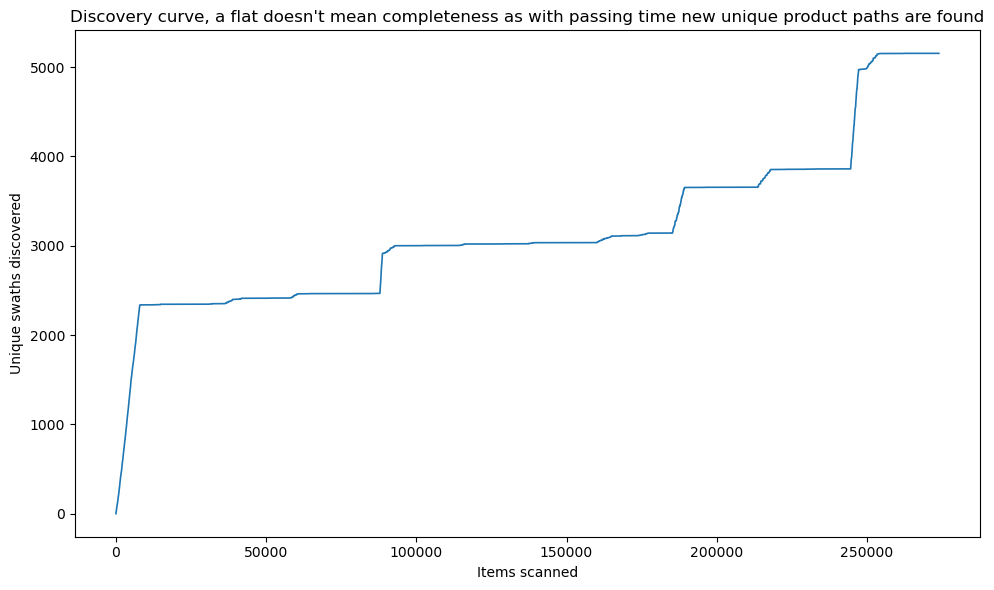

In the most recent 200000 scanned items: 2688 were new unique swaths (1.34%)


In [6]:
# DIAGNOSTIC; discovery curve: cumulative unique swaths vs cumulative scanned
import matplotlib.pyplot as plt
acq_df = pd.read_csv(ALL_ACQUISITIONS_CSV)
acq_df["datetime"] = pd.to_datetime(acq_df["datetime"])
acq_df = acq_df.sort_values("datetime").reset_index(drop=True)
acq_df["is_first_occurrence"] = ~acq_df["grid_code"].duplicated()
acq_df["cumulative_unique"] = acq_df["is_first_occurrence"].cumsum()
acq_df["cumulative_scanned"] = range(1, len(acq_df) + 1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(acq_df["cumulative_scanned"], acq_df["cumulative_unique"], linewidth=1.2)
ax.set_xlabel("Items scanned")
ax.set_ylabel("Unique swaths discovered")
ax.set_title("Discovery curve, a flat doesn't mean completeness as with passing time new unique product paths are found")
plt.tight_layout()
plt.show()

N = min(200_000, len(acq_df))
recent = acq_df.tail(N)
new_in_recent = recent["is_first_occurrence"].sum()
print(f"In the most recent {N} scanned items: {new_in_recent} were new unique swaths "
      f"({100 * new_in_recent / N:.2f}%)")

## 5. Visualization, Ocean / Coastal / Land Classified World Map

Reads `all_swaths.csv` fresh from disk (safe to run anytime, including mid-scan, to get an up-to-date snapshot), classifies each unique swath by
`ocean_fraction` against the thresholds set in Section 1, and plots them on a world map colored by category.

**Categories:**
- **Dark blue** ocean (`ocean_fraction >= OCEAN_THRESHOLD`)
- **Red** coastal (`LAND_ONLY_THRESHOLD < ocean_fraction < OCEAN_THRESHOLD`)
- **Dark green** land, outside the approximate restricted zone
- **Dark grey** land, inside the approximate North America / Europe restricted zone

### Important caveat on the "restricted zone"
ESA states BIOMASS's P-band radar is switched off within line-of-sight of US Space Object Tracking Radar (SOTR) stations, which "mainly excludes North America and Europe", but this is published only as a graphic, not as coordinates. The `EXCLUSION_BOXES` below are **rough rectangular approximations**, not the true SOTR line-of-sight boundary. Treat any grey/green boundary in the resulting plot as illustrative only. If precise boundaries are ever needed, this would require either digitizing ESA's published observation-mask graphic or locating an official coordinate release.
Coastlines use Natural Earth **50m** resolution (not the coarser 110m default), this matters most visually at Antarctica, whose complex coastline looks blocky/cropped at 110m.

5153 unique swath locations loaded
 2091 ocean (>= 0.95)
 740 coastal (0.05 < fraction < 0.95)
 2322 land (<= 0.05, outside restricted zone)
 0 land in approx N.America/Europe restricted zone


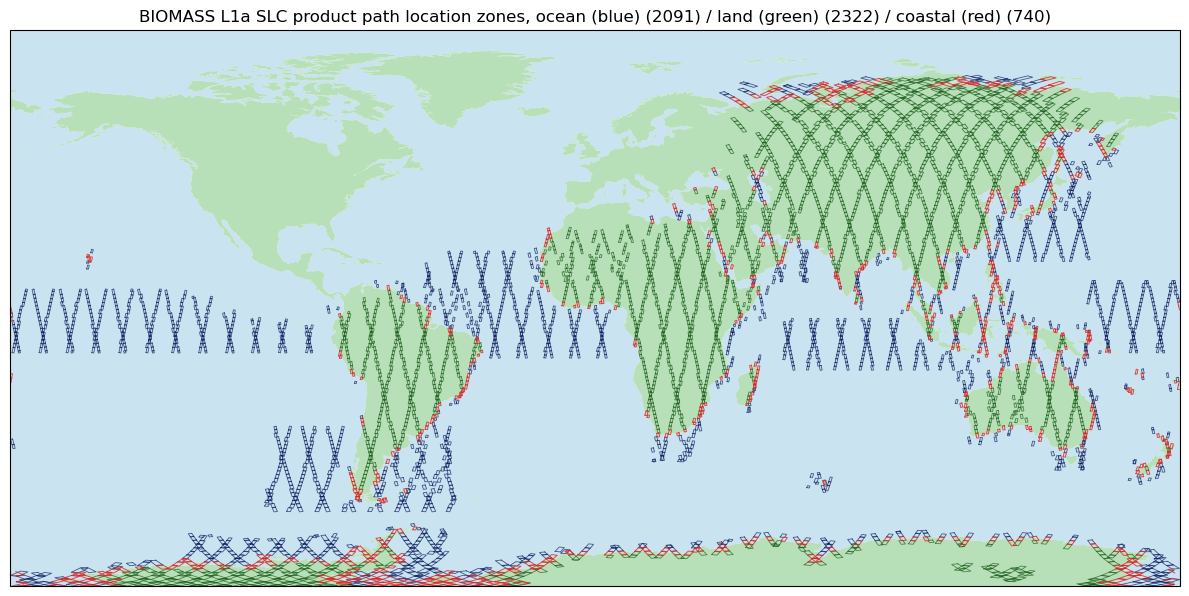

In [7]:
# VISUALIZATION; ocean/land/coastal/restricted-zone-land world map
from shapely import wkt as shapely_wkt
from shapely.geometry import box
from shapely.ops import unary_union
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

EXCLUSION_BOXES = [ # APPROXIMATE North America/Europe restricted zone (tightened to core landmass)
    box(-125, 25, -66, 49), # North America (approx); drops Alaska, far northern Canada, Central America
    box(-10, 36, 30, 60),   # Europe (approx); drops North Africa, western Russia, far northern Scandinavia
]
exclusion_union = unary_union(EXCLUSION_BOXES)
all_df = pd.read_csv(ALL_SWATHS_CSV)
swaths_geo = all_df.drop_duplicates(subset="grid_code").copy()
swaths_geo["geometry"] = swaths_geo["geometry_wkt"].apply(shapely_wkt.loads)
print(f"{len(swaths_geo)} unique swath locations loaded")

ocean_df = swaths_geo[swaths_geo["ocean_fraction"] >= OCEAN_THRESHOLD]
coastal_df = swaths_geo[(swaths_geo["ocean_fraction"] > LAND_ONLY_THRESHOLD) & (swaths_geo["ocean_fraction"] < OCEAN_THRESHOLD)]
land_df = swaths_geo[swaths_geo["ocean_fraction"] <= LAND_ONLY_THRESHOLD].copy()
land_df["in_restricted_zone"] = land_df["geometry"].apply(lambda g: g.centroid.intersects(exclusion_union))
land_restricted_df = land_df[land_df["in_restricted_zone"]]
land_normal_df = land_df[~land_df["in_restricted_zone"]]

print(f" {len(ocean_df)} ocean (>= {OCEAN_THRESHOLD})")
print(f" {len(coastal_df)} coastal ({LAND_ONLY_THRESHOLD} < fraction < {OCEAN_THRESHOLD})")
print(f" {len(land_normal_df)} land (<= {LAND_ONLY_THRESHOLD}, outside restricted zone)")
print(f" {len(land_restricted_df)} land in approx N.America/Europe restricted zone")

def plot_ring_dateline_safe(ax, xs, ys, **kwargs):
    """Plots a polygon ring, splitting it into separate segments wherever
    the path crosses the antimeridian, so it doesn't draw a spurious line
    all the way across the map."""
    xs = list(xs); ys = list(ys)
    if len(xs) < 2:
        return
    jumps = [i for i in range(1, len(xs)) if abs(xs[i] - xs[i - 1]) > 180]
    segments = []
    start = 0
    for j in jumps:
        segments.append((xs[start:j], ys[start:j]))
        start = j
    segments.append((xs[start:], ys[start:]))
    for seg_x, seg_y in segments:
        if len(seg_x) >= 2:
            ax.plot(seg_x, seg_y, transform=ccrs.PlateCarree(), **kwargs)

fig = plt.figure(figsize=(12, 20))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-180, 180, -81, 90], crs=ccrs.PlateCarree()) # Southern crop; pushes the visible map boundary north of the true pole so the dense, visually-compressed tangle of swath outlines over Antarctica doesn't dominate the plot.

# 50m resolution (not the coarse 110m default) matters most at Antarctica
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                          facecolor="#b8e0b8", edgecolor="none")
ocean_50m = cfeature.NaturalEarthFeature('physical', 'ocean', '50m',
                                           facecolor="#c9e3f0", edgecolor="none")
ax.add_feature(ocean_50m, zorder=0)
ax.add_feature(land_50m, zorder=0)

# draw order: land (normal), land (restricted), ocean, coastal on top
for geom in land_normal_df["geometry"]:
    geoms = [geom] if geom.geom_type == "Polygon" else list(geom.geoms)
    for g in geoms:
        xs, ys = g.exterior.xy
        plot_ring_dateline_safe(ax, xs, ys, color="#1a5c1a", linewidth=0.6, alpha=0.7)
for geom in land_restricted_df["geometry"]:
    geoms = [geom] if geom.geom_type == "Polygon" else list(geom.geoms)
    for g in geoms:
        xs, ys = g.exterior.xy
        plot_ring_dateline_safe(ax, xs, ys, color="#4d4d4d", linewidth=0.6, alpha=0.7)
for geom in ocean_df["geometry"]:
    geoms = [geom] if geom.geom_type == "Polygon" else list(geom.geoms)
    for g in geoms:
        xs, ys = g.exterior.xy
        plot_ring_dateline_safe(ax, xs, ys, color="#0a1a5c", linewidth=0.6, alpha=0.7)
for geom in coastal_df["geometry"]:
    geoms = [geom] if geom.geom_type == "Polygon" else list(geom.geoms)
    for g in geoms:
        xs, ys = g.exterior.xy
        plot_ring_dateline_safe(ax, xs, ys, color="#d62728", linewidth=0.7, alpha=0.8)

ax.set_title(f"BIOMASS L1a SLC product path location zones, ocean (blue) ({len(ocean_df)}) / land (green) ({len(land_normal_df)}) / coastal (red) ({len(coastal_df)})")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ocean_land_restricted_coastal_swaths.png", dpi=150, bbox_inches="tight")
plt.show()

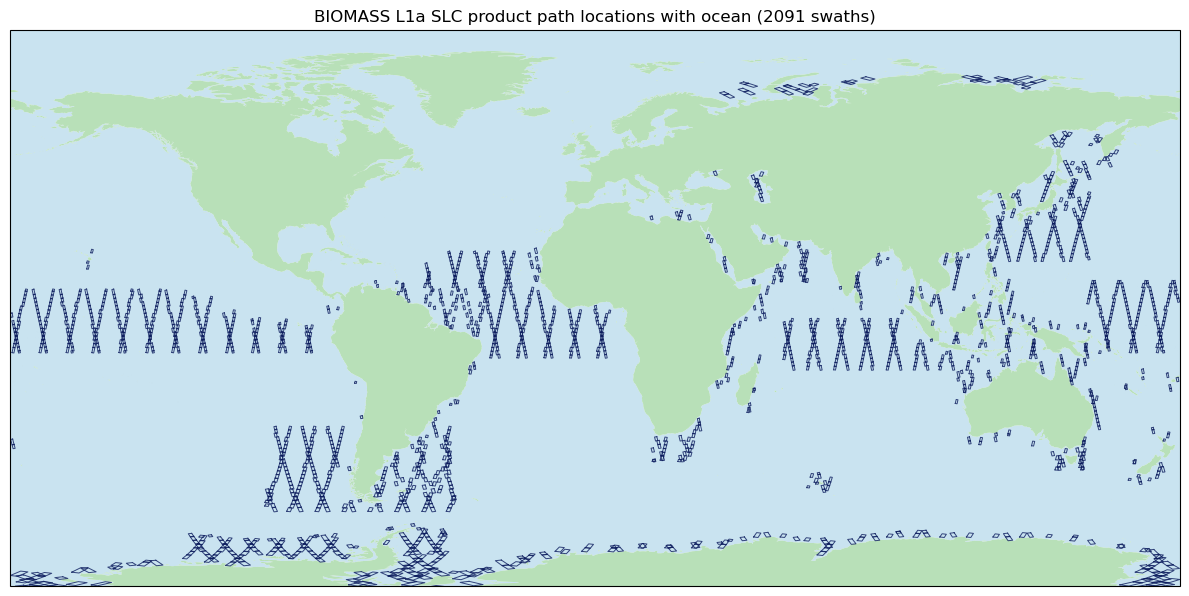

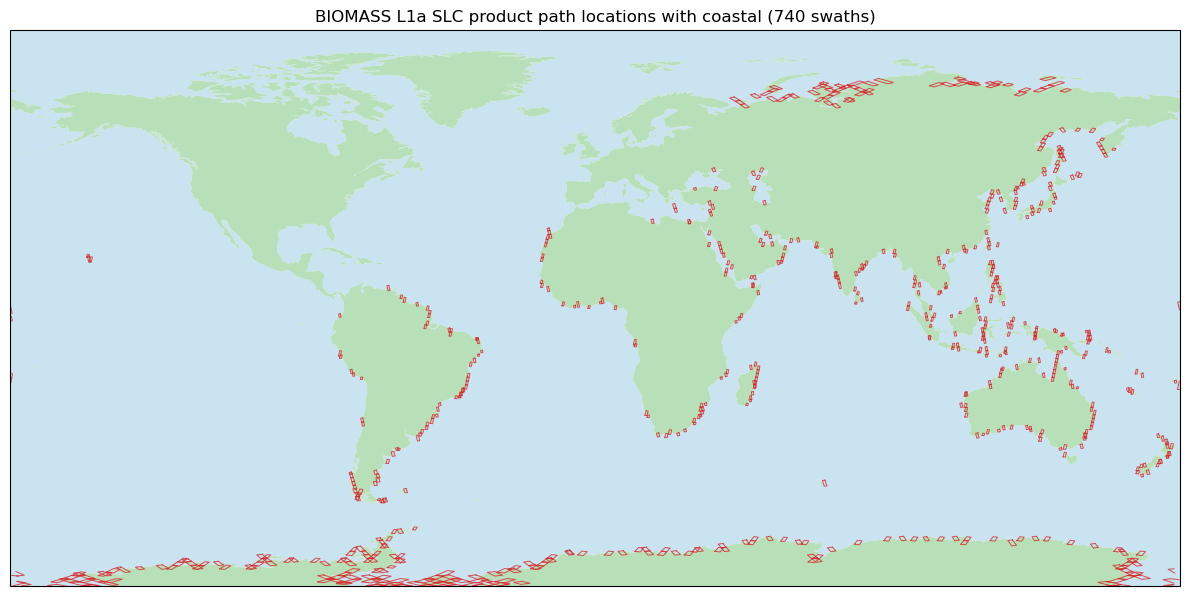

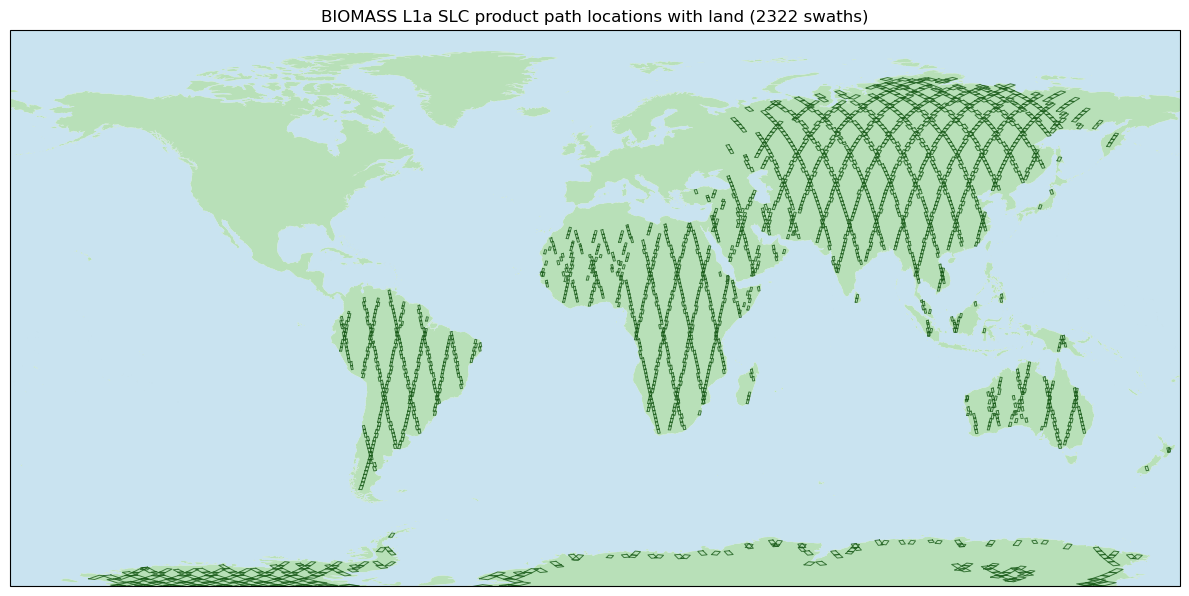

2091 ocean / 740 coastal / 2322 land, 3 maps saved to C:\Users\Orlaith.Doyle\STEP_BACK\sidequest_check


In [8]:
# CLASSIFICATION CHECK; plot ocean / coastal / land swaths as three SEPARATE maps (rather than one combined map with all three overlaid).
from shapely import wkt as shapely_wkt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_ring_dateline_safe(ax, xs, ys, **kwargs):
    xs = list(xs); ys = list(ys)
    if len(xs) < 2:
        return
    jumps = [i for i in range(1, len(xs)) if abs(xs[i] - xs[i - 1]) > 180]
    segments = []
    start = 0
    for j in jumps:
        segments.append((xs[start:j], ys[start:j]))
        start = j
    segments.append((xs[start:], ys[start:]))
    for seg_x, seg_y in segments:
        if len(seg_x) >= 2:
            ax.plot(seg_x, seg_y, transform=ccrs.PlateCarree(), **kwargs)

all_df = pd.read_csv(ALL_SWATHS_CSV)
swaths_geo = all_df.drop_duplicates(subset="grid_code").copy()
swaths_geo["geometry"] = swaths_geo["geometry_wkt"].apply(shapely_wkt.loads)
ocean_df = swaths_geo[swaths_geo["ocean_fraction"] >= OCEAN_THRESHOLD]
coastal_df = swaths_geo[(swaths_geo["ocean_fraction"] > LAND_ONLY_THRESHOLD) & (swaths_geo["ocean_fraction"] < OCEAN_THRESHOLD)]
land_df = swaths_geo[swaths_geo["ocean_fraction"] <= LAND_ONLY_THRESHOLD]

CATEGORIES = [
    ("ocean",   ocean_df,   "#0a1a5c"),
    ("coastal", coastal_df, "#d62728"),
    ("land",    land_df,    "#1a5c1a"),
]

for label, df, color in CATEGORIES:
    fig = plt.figure(figsize=(12, 9))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-180, 180, -81, 90], crs=ccrs.PlateCarree())

    land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m', facecolor="#b8e0b8", edgecolor="none")
    ocean_50m = cfeature.NaturalEarthFeature('physical', 'ocean', '50m', facecolor="#c9e3f0", edgecolor="none")
    ax.add_feature(ocean_50m, zorder=0)
    ax.add_feature(land_50m, zorder=0)

    for geom in df["geometry"]:
        geoms = [geom] if geom.geom_type == "Polygon" else list(geom.geoms)
        for g in geoms:
            xs, ys = g.exterior.xy
            plot_ring_dateline_safe(ax, xs, ys, color=color, linewidth=0.7, alpha=0.8)

    ax.set_title(f"BIOMASS L1a SLC product path locations with {label} ({len(df)} swaths)")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"swaths_{label}_only.png", dpi=150, bbox_inches="tight")
    plt.show()

print(f"{len(ocean_df)} ocean / {len(coastal_df)} coastal / {len(land_df)} land, 3 maps saved to {OUTPUT_DIR}")

# 5.2. Smaller continent and country specific availability check, 

This filters swaths to a specific area (e.g. Africa, South America, Asia, Australia). It outputs a report & plot of just that subset. Reuses ALL_SWATHS_CSV, so run after the scan has produced some data. Two ways to define the region:
 1. Pick a name from REGION_BOXES (quick, approximate bounding boxes) or
 2. Pass your own custom shapely geometry / bounding box

*Bounding boxes are approximate rectangles, not true country/continent borders, they're fine for a quick "did we get coverage here" check, but will include some neighboring land/ocean at the edges (e.g. the Africa box catches a sliver of the Arabian Peninsula and southern Europe). If you need a precise continent outline instead swap this to Natural Earth continent polygons via geopandas.*

5153 unique swaths total
277 swaths intersect 'Australia'
  ocean fraction range: -0.00 - 1.00
  orbit states: {'descending': 139, 'ascending': 138}
  date range: 2025-11-21T09:08:19.128Z to 2026-07-04T19:52:03.309Z
13906 total acquisitions (incl. repeats) across those 277 swath locations


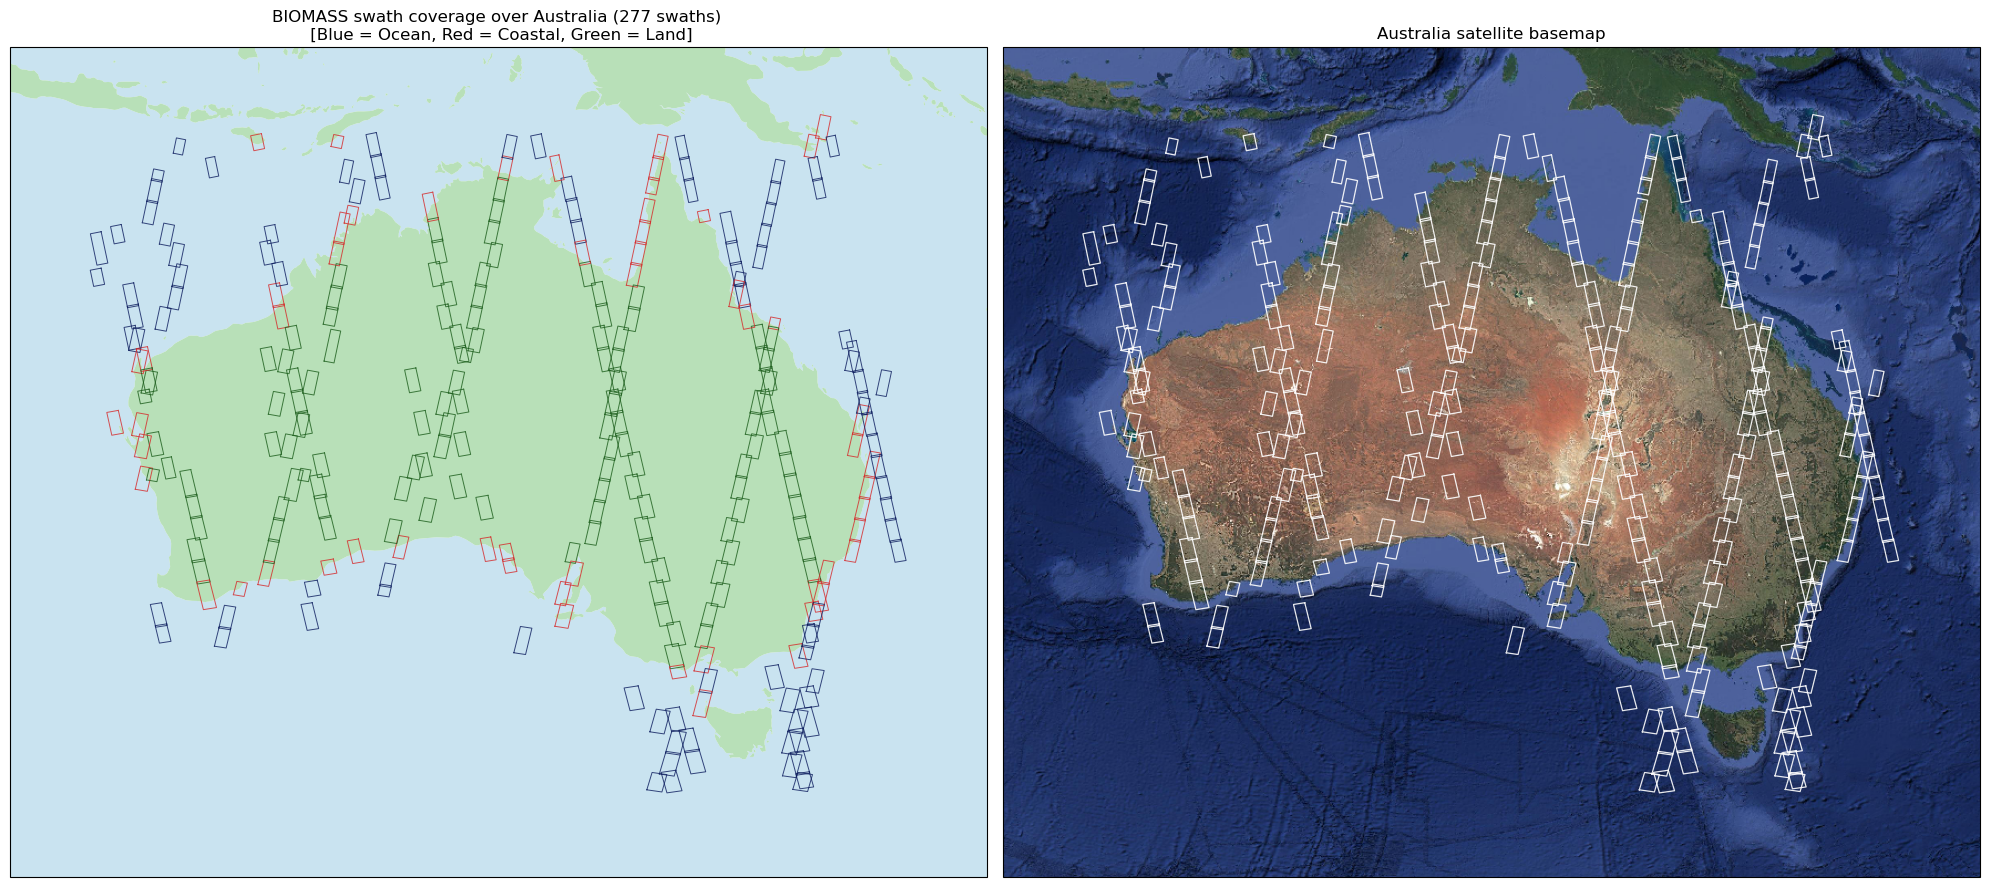

In [14]:
from shapely import wkt as shapely_wkt
from shapely.geometry import box, Polygon, MultiPolygon
from shapely.affinity import translate
from shapely.ops import unary_union
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.img_tiles import GoogleTiles

REGION_BOXES = {
    "Africa":        box(-20, -35, 55, 38),
    "South_America": box(-82, -56, -34, 13),
    "North_America": box(-170, 5, -50, 75), # Remember: Limited products available due to restrictions
    "Europe":        box(-25, 35, 40, 72), # Remember: Limited products available due to restrictions
    "Asia":          box(40, -10, 180, 78),
    "Australia":     box(112, -45, 155, -10),
    "Antarctica":    box(-180, -90, 180, -60),
}
"""Bounding boxes for coastal countries with ocean/SSS relevance, covering all continents 
EXCEPT Europe (excluded per export restrictions) and North America (excluded except for its far-south / Central America & Caribbean countries,
which sit outside the restricted-zone box already in REGION_BOXES).Landlocked countries are intentionally omitted, no coastline means no
relevance to ocean/coastal swath validation. 
Same caveat as before: rectangles, not true borders, corners will catch a bit of neighboring land/ocean/countries."""

COUNTRY_BOXES = {

    # Central America & Caribbean (far-south North America)
    "Mexico":            box(-118, 14, -86, 33),
    "Guatemala":         box(-92.5, 13.5, -88, 17.9),
    "Belize":            box(-89.3, 15.9, -88, 18.5),
    "Honduras":          box(-89.4, 12.9, -83, 16.5),
    "El_Salvador":       box(-90.1, 13.1, -87.7, 14.5),
    "Nicaragua":         box(-87.7, 10.7, -83, 15),
    "Costa_Rica":        box(-86, 8, -82.5, 11.2),
    "Panama":            box(-83, 7, -77, 9.7),
    "Cuba":              box(-85, 19.8, -74, 23.3),
    "Dominican_Republic": box(-72.1, 17.5, -68.3, 19.9),
    "Jamaica":           box(-78.4, 17.6, -76.1, 18.6),
    "Bahamas":           box(-79, 20.9, -72.7, 27.3),

    # South America
    "Brazil":            box(-74, -34, -34, 6),
    "Argentina":         box(-74, -55, -53, -22),
    "Chile":             box(-76, -56, -66, -17),
    "Peru":              box(-82, -18, -68, 0),
    "Colombia":          box(-79, -4, -66, 13),
    "Venezuela":         box(-73, 0, -59, 12),
    "Ecuador":           box(-81, -5, -75, 1.5),
    "Uruguay":           box(-58, -35, -53, -30),
    "Guyana":            box(-61, 1, -56, 8.5),
    "Suriname":          box(-58, 1.8, -54, 6),

    # Africa
    "Morocco":           box(-17.1, 27.6, -1, 35.9),
    "Algeria":           box(-8.7, 18.9, 12, 37.1),
    "Tunisia":           box(7.5, 30.2, 11.6, 37.6),
    "Libya":             box(9.3, 19.5, 25.2, 33.2),
    "Egypt":             box(25, 22, 37, 32),
    "Sudan":             box(21.8, 8.7, 38.6, 22),
    "Eritrea":           box(36.4, 12.4, 43.1, 18),
    "Djibouti":          box(41.7, 10.9, 43.4, 12.7),
    "Somalia":           box(40.9, -1.7, 51.4, 12),
    "Kenya":             box(34, -5, 42, 5),
    "Tanzania":          box(29.3, -11.7, 40.4, -1),
    "Mozambique":        box(30.2, -26.9, 40.8, -10.5),
    "South_Africa":      box(16, -35, 33, -22),
    "Namibia":           box(11.7, -28.9, 25.3, -16.9),
    "Angola":            box(11.7, -18, 24.1, -4.4),
    "DR_Congo":          box(12.2, -13.5, 31.3, 5.4),  # small coastline near Congo river mouth
    "Congo":             box(11.1, -5, 18.6, 3.7),
    "Gabon":             box(8.7, -3.9, 14.5, 2.3),
    "Cameroon":          box(8.5, 1.7, 16.2, 13.1),
    "Nigeria":           box(2, 4, 15, 14),
    "Ghana":             box(-3.3, 4.7, 1.2, 11.2),
    "Ivory_Coast":       box(-8.6, 4.3, -2.5, 10.7),
    "Senegal":           box(-17.6, 12.3, -11.3, 16.7),
    "Mauritania":        box(-17.1, 14.7, -4.8, 27.3),
    "Madagascar":        box(43.2, -25.6, 50.5, -11.9),

    # Asia / Middle East
    "Russia":            box(19, 41, 180, 82),  # touches the antimeridian in the far east (Chukotka), same seam issue as Asia; add "Russia": ~100 to REGION_CENTRAL_LON if plotting shows the same artifact
    "China":             box(73, 18, 135, 54),
    "North_Korea":       box(124.3, 37.7, 130.7, 43),
    "South_Korea":       box(125, 33, 130, 39),
    "Japan":             box(129, 31, 146, 46),
    "India":             box(68, 6, 97, 36),
    "Pakistan":          box(60.9, 23.6, 77.8, 37.1),
    "Bangladesh":        box(88, 20.7, 92.7, 26.6),
    "Myanmar":           box(92.2, 9.8, 101.2, 28.5),
    "Thailand":          box(97.3, 5.6, 105.6, 20.5),
    "Vietnam":           box(102.1, 8.6, 109.5, 23.4),
    "Malaysia":          box(99.6, 0.9, 119.3, 7.4),
    "Philippines":       box(116.9, 4.6, 126.6, 21.1),
    "Indonesia":         box(95, -11, 141, 6),
    "Saudi_Arabia":      box(34, 16, 56, 33),
    "UAE":               box(51, 22.6, 56.4, 26.1),
    "Iran":              box(44, 25, 63.3, 39.8),
    "Oman":              box(52, 16.6, 59.8, 26.4),
    "Yemen":             box(42.5, 12.1, 54, 19),
    "Sri_Lanka":         box(79.5, 5.9, 81.9, 9.9),
    "Turkey":            box(26, 36, 45, 42),

    # Oceania
    "Australia":         box(112, -45, 155, -10),
    "New_Zealand":       box(166, -47, 179, -34),
    "Papua_New_Guinea":  box(140.8, -11.7, 155.6, -1),
    "Fiji":              box(177, -21, 180, -12),  # simplified; Fiji's easternmost islands cross the antimeridian; this box only covers the western part
}

REGION_BOXES.update(COUNTRY_BOXES)  # merge so REGION_NAME can pick either a continent or a country by name
###############################################################################################################
###############################################################################################################
###############################################################################################################
# GOLDEN line input for continent or country here
REGION_NAME = "Australia"  # change to any key; continents from the original REGION_BOXES, or any individual country name from COUNTRY_BOXES (e.g. "Japan", "Brazil", "Kenya")

###############################################################################################################
###############################################################################################################
###############################################################################################################
# or set REGION_GEOM manually below
REGION_GEOM = REGION_BOXES[REGION_NAME]
"""Default map projection is centered on longitude 0, which puts its seam at +-180. Any region box that touches or is near +-180
(Asia's box runs right up to 180) makes set_extent ambiguous about which "way around" to show... in practice it tends to fall back
to showing almost the entire globe. The fix is to recenter the axes' own projection away from the region's data, so the seam lands
somewhere empty instead of in the middle of what you're trying to look at. Cartopy then reprojects the raw (un-doctored) lon/lat
points correctly on its own, no manual coordinate math needed for display."""

REGION_CENTRAL_LON = {
    "Asia": 110,  # roughly the center of Asia's box (40 to 180) pushes the seam to 70, far from any Asia swaths
}

# Satellite basemap panel,shown side-by-side with the schematic map below.
# GoogleTiles fetches real satellite imagery tiles at render time, so it needs
# an internet connection when the cell runs. ZOOM_LEVEL controls tile detail
# vs. fetch time: ~4-5 for a full continent, ~6-7 for a single country, ~8+
# for a small area, higher is slower since more tiles get downloaded.
ZOOM_LEVEL = 6
SATELLITE_TILER = GoogleTiles(style="satellite")

# Antimeridian repair!
"""Root cause: a swath footprint that genuinely crosses the dateline gets stored as raw lon/lat WKT with a jump from ~+179 to ~-179.
Shapely has no concept of the sphere wrapping around, it reads that as a polygon stretching almost the full width of the map.
That corrupted shape then breaks TWO things: the .intersects() test used to build region_df (it spuriously overlaps boxes
it has no business touching), and the plot (it draws as a huge smear). Fixing it only at plot time (as before) can't undo a
selection that already went wrong. So this fixes the geometry itself, before either step touches it."""

def unwrap_lons(xs):
    xs = list(xs)
    for i in range(1, len(xs)):
        while xs[i] - xs[i - 1] > 180:
            xs[i] -= 360
        while xs[i] - xs[i - 1] < -180:
            xs[i] += 360
    return xs

def _unwrap_ring(coords):
    xs, ys = zip(*coords)
    return list(zip(unwrap_lons(list(xs)), ys))

def fix_polygon_dateline(poly):
    """Re-expresses a polygon's rings in a continuous (possibly >180 or <-180)
    coordinate space so its true shape is preserved instead of jumping across
    the map. May produce a polygon that extends outside [-180, 180], that's
    expected and handled by the duplicate-and-shift step below."""
    ext = _unwrap_ring(list(poly.exterior.coords))
    interiors = [_unwrap_ring(list(r.coords)) for r in poly.interiors]
    try:
        return Polygon(ext, interiors)
    except Exception:
        return poly  # fall back to original if something degenerate happens

def fix_geom_dateline(geom):
    if geom.geom_type == "Polygon":
        return fix_polygon_dateline(geom)
    elif geom.geom_type == "MultiPolygon":
        return MultiPolygon([fix_polygon_dateline(p) for p in geom.geoms])
    return geom

def dateline_safe_geom(geom):
    """After unwrapping, the polygon may now live partly outside [-180, 180]
    (e.g. spanning 170 to 190). Region boxes are defined in standard [-180,
    180] space, so we union in copies shifted by +-360, this guarantees an
    accurate .intersects() test no matter which direction the original data
    wrapped, without needing to know in advance."""
    fixed = fix_geom_dateline(geom)
    return unary_union([fixed, translate(fixed, xoff=360), translate(fixed, xoff=-360)])

all_df = pd.read_csv(ALL_SWATHS_CSV)
swaths_geo = all_df.drop_duplicates(subset="grid_code").copy()
swaths_geo["geometry"] = swaths_geo["geometry_wkt"].apply(shapely_wkt.loads)

# Selection now uses the dateline-safe geometry instead of the raw one.
region_df = swaths_geo[swaths_geo["geometry"].apply(lambda g: dateline_safe_geom(g).intersects(REGION_GEOM))].copy()

print(f"{len(swaths_geo)} unique swaths total")
print(f"{len(region_df)} swaths intersect '{REGION_NAME}'")
if len(region_df):
    print(f"  ocean fraction range: {region_df['ocean_fraction'].min():.2f} - {region_df['ocean_fraction'].max():.2f}")
    print(f"  orbit states: {region_df['orbit_state'].value_counts().to_dict()}")
    print(f"  date range: {region_df['datetime'].min()} to {region_df['datetime'].max()}")

if ALL_ACQUISITIONS_CSV.exists():
    acq_df = pd.read_csv(ALL_ACQUISITIONS_CSV)
    region_grid_codes = set(region_df["grid_code"])
    region_acq_df = acq_df[acq_df["grid_code"].isin(region_grid_codes)]
    print(f"{len(region_acq_df)} total acquisitions (incl. repeats) across those {len(region_grid_codes)} swath locations")

# Drop degenerate footprints
""""A real BIOMASS swath is a narrow strip, physically only a few hundred km wide.
But a fixed DEGREE threshold on longitude span is wrong globally: meridians converge toward the poles, so the same physical width covers far
more degrees of longitude near Antarctica than near the equator. A raw degree cutoff correctly caught Asia's corrupted footprints but wrongly
flagged Antarctica's perfectly normal ones. Converting to actual physical width (km) using each swath's own latitude fixes this everywhere at once."""

import math

MAX_REASONABLE_WIDTH_KM = 1200  # generous upper bound for a real swath's width

def lon_span_km(geom):
    minx, miny, maxx, maxy = geom.bounds
    lon_span_deg = maxx - minx
    mean_lat = (miny + maxy) / 2
    km_per_deg_lon = 111.32 * math.cos(math.radians(mean_lat))
    return lon_span_deg * km_per_deg_lon

region_df["width_km"] = region_df["geometry"].apply(lon_span_km)
suspect = region_df[region_df["width_km"] > MAX_REASONABLE_WIDTH_KM]
if len(suspect):
    print(f"\nExcluding {len(suspect)} swath(s) with implausible width "
          f"(>{MAX_REASONABLE_WIDTH_KM} km), likely corrupted/fallback footprints:")
    print(suspect[["id", "width_km"]].to_string(index=False))
    region_df = region_df[region_df["width_km"] <= MAX_REASONABLE_WIDTH_KM].copy()

if len(region_df):
    is_antarctica = REGION_NAME == "Antarctica"

    # Side-by-side layout: left panel keeps the original schematic map exactly
    # as before, right panel is a new satellite-imagery panel sharing the same
    # projection and extent, with the same swaths drawn on top of it.
    if is_antarctica:
        proj = ccrs.SouthPolarStereo()
    else:
        central_lon = REGION_CENTRAL_LON.get(REGION_NAME, 0)
        proj = ccrs.PlateCarree(central_longitude=central_lon)

    fig = plt.figure(figsize=(20, 10))
    ax = fig.add_subplot(1, 2, 1, projection=proj)
    ax_sat = fig.add_subplot(1, 2, 2, projection=proj)

    if is_antarctica:
        ax.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
        ax.gridlines(draw_labels=False, linestyle=":", alpha=0.4)
        ax_sat.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
        ax_sat.gridlines(draw_labels=False, linestyle=":", alpha=0.4)
    else:
        minx, miny, maxx, maxy = REGION_GEOM.bounds
        pad = 5
        # extent is still expressed in standard (central_longitude=0) coordinates
        # cartopy transforms it into the recentered axes correctly via the crs= arg
        ax.set_extent([minx - pad, maxx + pad, miny - pad, maxy + pad], crs=ccrs.PlateCarree())
        ax_sat.set_extent([minx - pad, maxx + pad, miny - pad, maxy + pad], crs=ccrs.PlateCarree())

    land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m', facecolor="#b8e0b8", edgecolor="none")
    ocean_50m = cfeature.NaturalEarthFeature('physical', 'ocean', '50m', facecolor="#c9e3f0", edgecolor="none")
    ax.add_feature(ocean_50m, zorder=0)
    ax.add_feature(land_50m, zorder=0)

    # Real satellite/terrain imagery for the right panel, Google-Earth-style.
    ax_sat.add_image(SATELLITE_TILER, ZOOM_LEVEL)

    for geom, frac in zip(region_df["geometry"], region_df["ocean_fraction"]):
        color = "#0a1a5c" if frac >= OCEAN_THRESHOLD else ("#d62728" if frac > LAND_ONLY_THRESHOLD else "#1a5c1a")
        # Plot the RAW geometry, with the axes recentered away from the seam, cartopy's transform correctly reprojects
        # antimeridian-crossing points on its own, so no manual unwrapping is needed for display purposes.
        # (fix_geom_dateline is still used above for the .intersects() selection step, since shapely itself has no
        # notion of the sphere wrapping.)
        geoms = [geom] if geom.geom_type == "Polygon" else list(geom.geoms)
        for g in geoms:
            xs, ys = g.exterior.xy
            ax.plot(list(xs), list(ys), transform=ccrs.PlateCarree(), color=color, linewidth=0.7, alpha=0.8)
            # Same outline drawn again on the satellite panel; white instead of the
            # dark schematic colors, since dark blue/green disappear against imagery.
            ax_sat.plot(list(xs), list(ys), transform=ccrs.PlateCarree(), color="white", linewidth=0.9, alpha=0.9)

    ax.set_title(f"BIOMASS swath coverage over {REGION_NAME} ({len(region_df)} swaths) \n [Blue = Ocean, Red = Coastal, Green = Land]")
    ax_sat.set_title(f"{REGION_NAME} satellite basemap")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"region_{REGION_NAME}_swaths.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"No swaths found intersecting '{REGION_NAME}', nothing to plot.")

## Appendix: output files reference
| File | Contents |
|---|---|
| `scan_state.json` | Resume checkpoint: scanned count, seen grid codes, last datetime, boundary ids |
| `all_swaths.csv` | One row per **unique** `grid_code`, geometry (WKT), `ocean_fraction`, `orbit_state`, first-seen datetime |
| `all_acquisitions.csv` | One row per **individual acquisition**, including repeats, no geometry (join back to `all_swaths.csv` via `grid_code` if needed) |
| `ocean_land_restricted_coastal_swaths.png` | The final classified world map |
| `region_{REGION_NAME}_swaths.png` | Swaths intersecting a specific continent or country (from `REGION_BOXES`/`COUNTRY_BOXES`), cropped to that area |
| `swaths_{ocean\|coastal\|land}_only.png` | Full-world map for a single classification category, plotted separately |

Both CSVs are append-only across sessions, safe to read from at any time, including mid-scan.